In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../dataset/bengaluru_house_prices.csv")

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 13320
Columns : 9


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

society         5502
balcony          609
bath              73
size              16
location           1
area_type          0
availability       0
total_sqft         0
price              0
dtype: int64

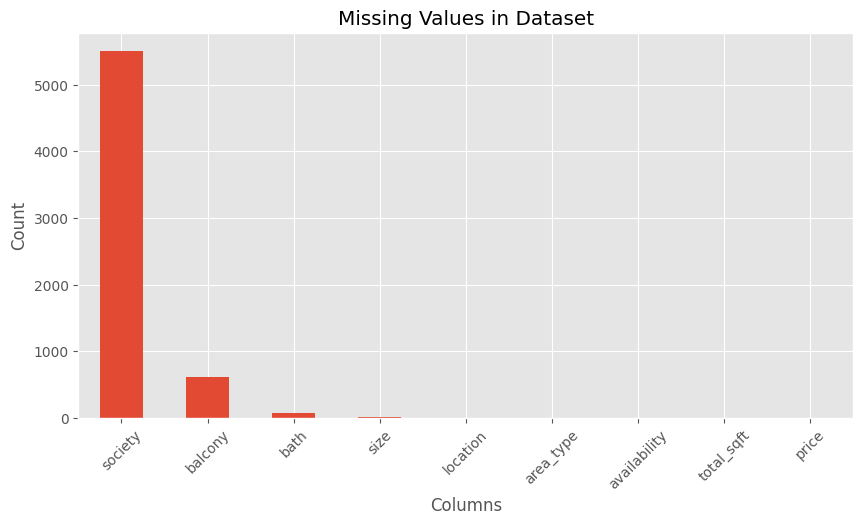

In [5]:
plt.figure(figsize=(10,5))

missing.plot(kind="bar")

plt.title("Missing Values in Dataset")
plt.xlabel("Columns")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

- Society has the highest number of missing values.
- Balcony and bath also contain missing values.
- Missing values need preprocessing before model training.

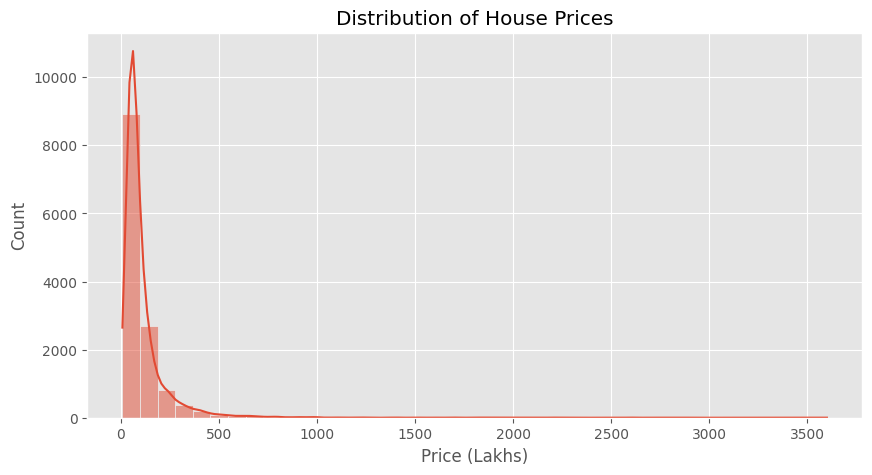

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=40, kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("Price (Lakhs)")

plt.show()

### Observation

- Most house prices are concentrated below 150 Lakhs.
- A few very expensive houses create a right-skewed distribution.
- Outliers are present.

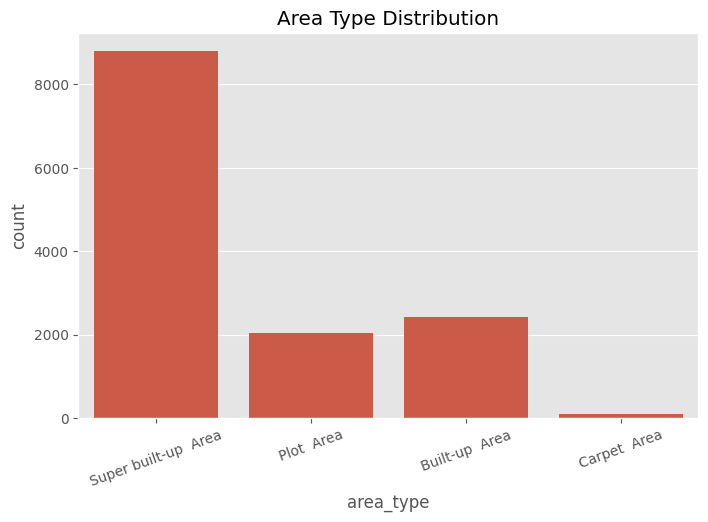

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="area_type")

plt.xticks(rotation=20)

plt.title("Area Type Distribution")

plt.show()

### Observation

- Super Built-up Area has the highest number of properties.
- Carpet Area and Plot Area are comparatively fewer.

In [9]:
df["BHK"] = df["size"].str.extract("(\d+)")

df["BHK"] = pd.to_numeric(df["BHK"])

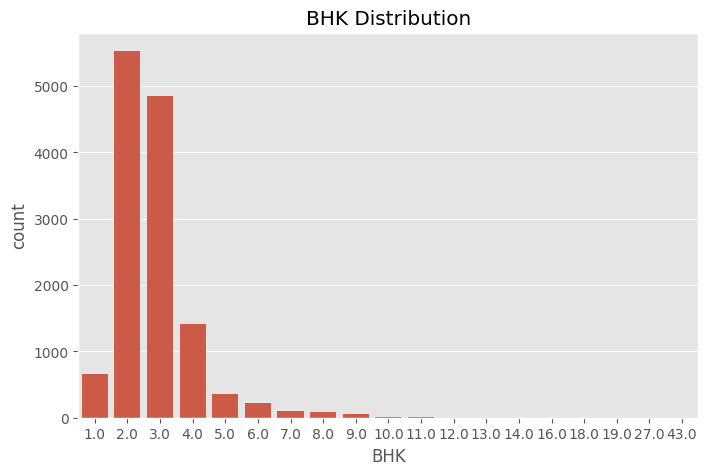

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="BHK")

plt.title("BHK Distribution")

plt.show()

### Observation

- 2 BHK and 3 BHK houses dominate the dataset.
- Very large BHK values are comparatively rare.

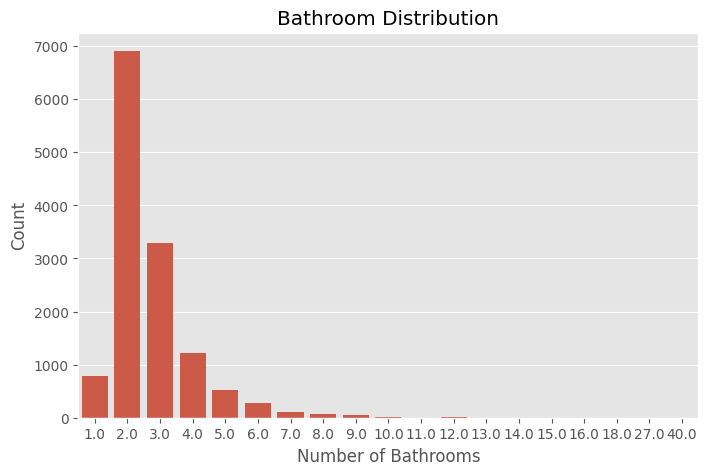

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="bath")

plt.title("Bathroom Distribution")

plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")

plt.show()

### Observation

- Most houses have 2 bathrooms.
- Very high bathroom counts are uncommon and may indicate luxury properties.

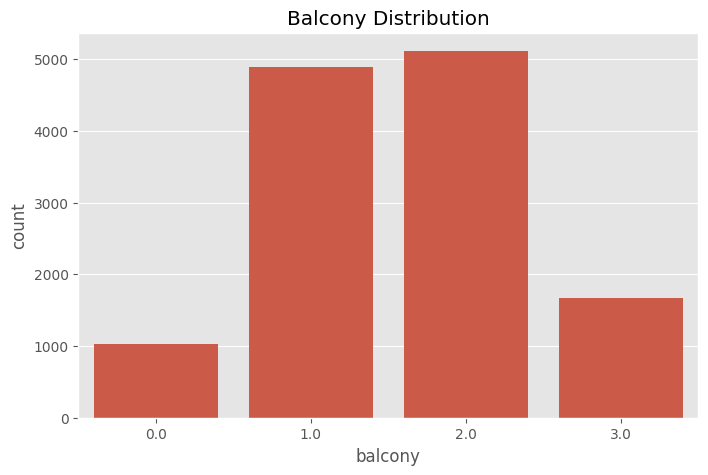

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="balcony")

plt.title("Balcony Distribution")

plt.show()

### Observation

- Most properties have 1 or 2 balconies.
- A few records have no balcony information due to missing values.

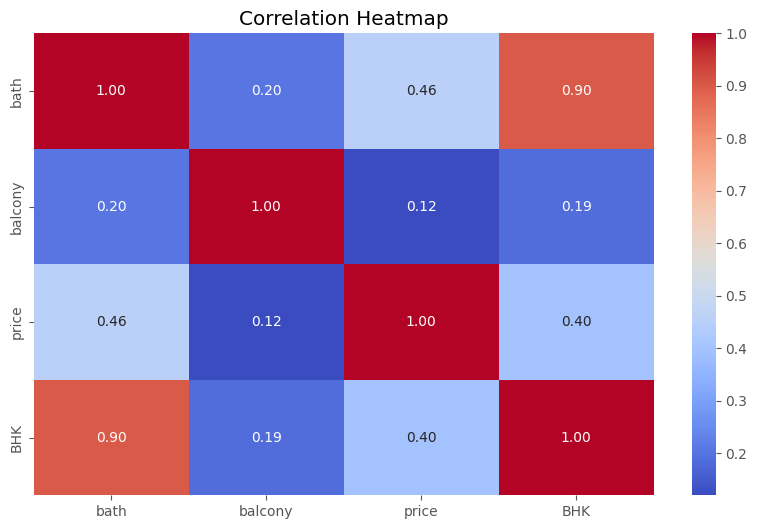

In [13]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Price has a strong positive correlation with bathrooms and balconies.
- Numerical features show useful relationships for prediction.

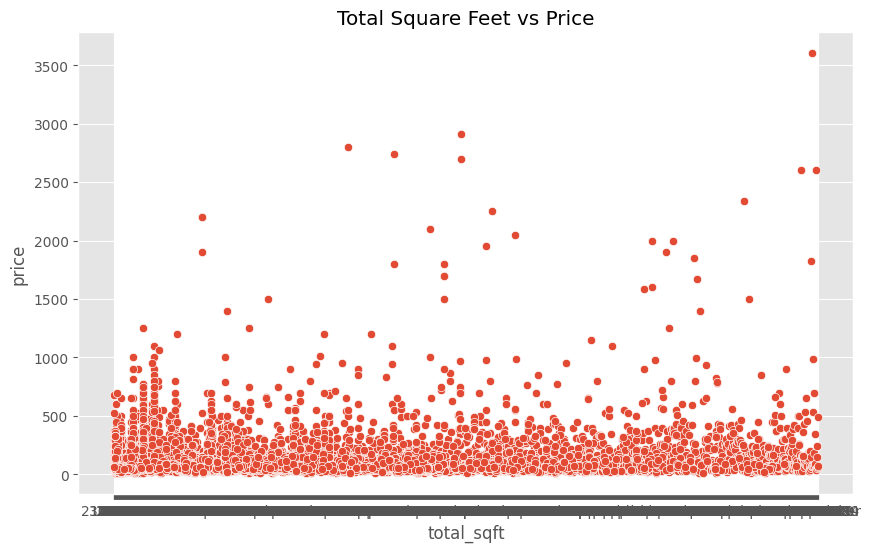

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="total_sqft",
    y="price",
    data=df
)

plt.title("Total Square Feet vs Price")

plt.show()

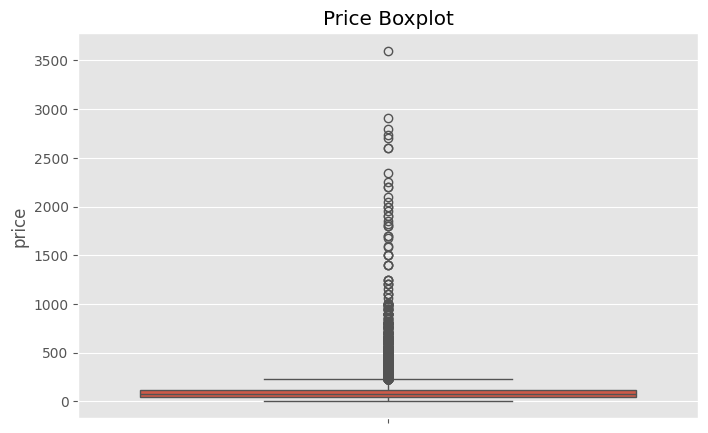

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["price"])

plt.title("Price Boxplot")

plt.show()

### Observation

- Several outliers are visible.
- These outliers should be investigated before model training.

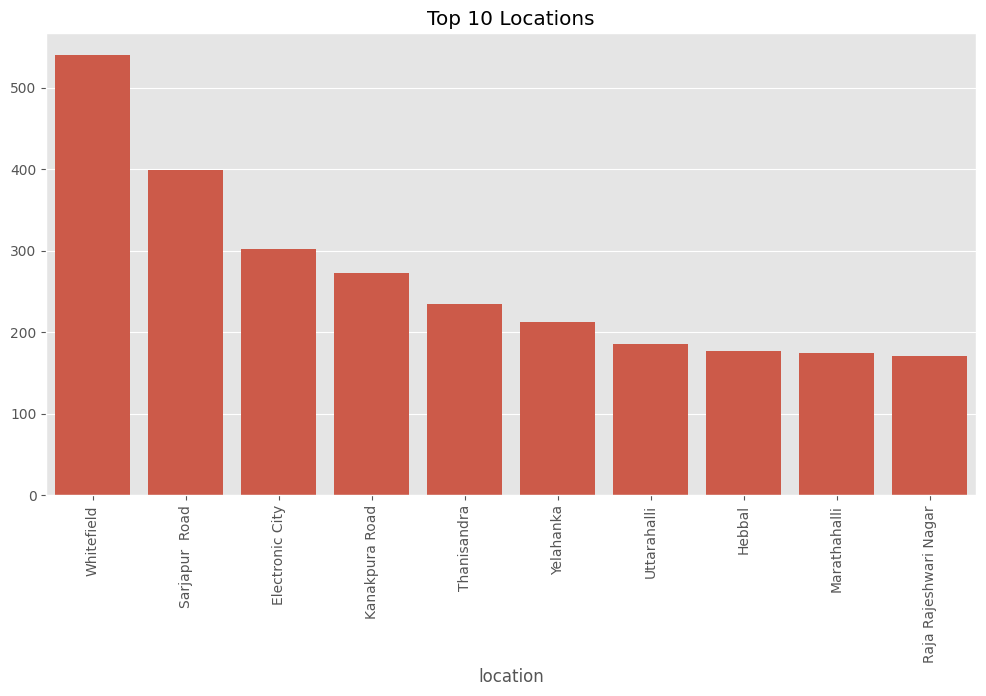

In [17]:
top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.index,
    y=top_locations.values
)

plt.xticks(rotation=90)

plt.title("Top 10 Locations")

plt.show()

### Observation

- A small number of locations account for many properties.
- This indicates location is an important feature.

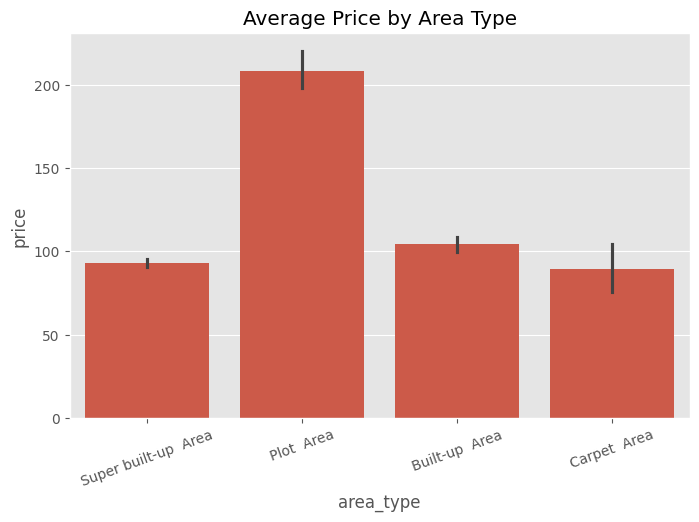

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="area_type",
    y="price"
)

plt.xticks(rotation=20)

plt.title("Average Price by Area Type")

plt.show()

### Observation

- Plot Area properties generally have higher prices.
- Area type influences property value.

# EDA Summary

### Key Findings

- Most houses are 2 BHK and 3 BHK.
- Most houses have 2 bathrooms.
- Price distribution is right-skewed.
- Outliers exist in the price column.
- Location plays a significant role in pricing.
- Missing values exist in society, balcony, and bath.
- Feature engineering is required before model training.